In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("/content/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

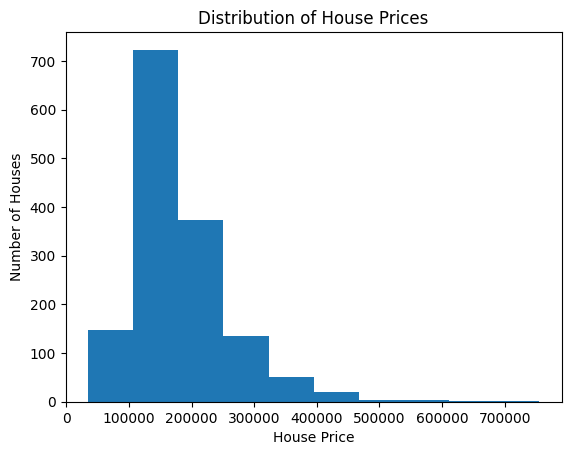

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["SalePrice"], bins=10)
plt.xlabel("House Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

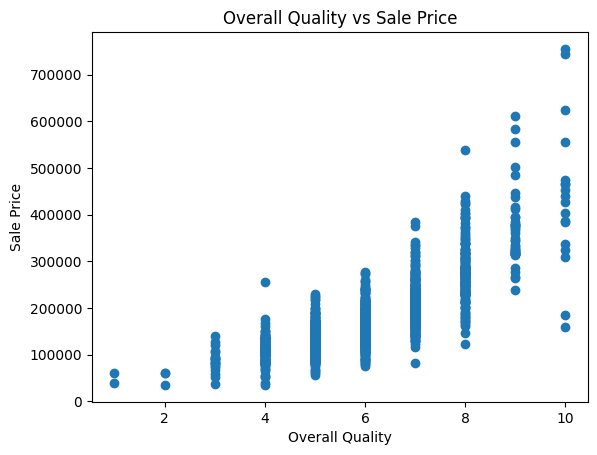

In [ ]:
import matplotlib.pyplot as plt

# Create a scatter plot.
# X-axis = OverallQual (overall quality of the house)
# Y-axis = SalePrice (selling price of the house)
# Each dot represents ONE house in our dataset.
plt.scatter(df["OverallQual"], df["SalePrice"])

# Give the X-axis a name.
plt.xlabel("Overall Quality")

# Give the Y-axis a name.
plt.ylabel("Sale Price")

# Give the graph a title.
plt.title("Overall Quality vs Sale Price")

# Display the graph.
plt.show()

In [ ]:
correlation=df["OverallQual"].corr(df["SalePrice"])
print(correlation)

0.7909816005838044


In [ ]:
correlation = df.corr(numeric_only=True)
saleprice_corr = correlation["SalePrice"]
saleprice_corr = saleprice_corr.sort_values()
print(saleprice_corr)

KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
Id              -0.021917
MiscVal         -0.021190
BsmtHalfBath    -0.016844
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
BsmtFullBath     0.227122
LotArea          0.263843
HalfBath         0.284108
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
FullBath         0.560664
1stFlrSF         0.605852
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePr

In [ ]:
saleprice_corr = df.corr(numeric_only=True)["SalePrice"]
strong_corr = saleprice_corr.abs().sort_values(ascending=False)
print(strong_corr.head(10))



SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [ ]:
missing_values=df.isnull().sum()
print(missing_values[missing_values>0])

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64


In [ ]:
# Missing means the feature does not exist
# So replace NaN with "None"

categorical_none_cols = [
    "Alley",
    "MasVnrType",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Fence",
    "MiscFeature"
]

for col in categorical_none_cols:
    df[col] = df[col].fillna("None")

In [ ]:
numeric_median_cols = [
    "LotFrontage",
    "MasVnrArea",
    "GarageYrBlt"
]

for col in numeric_median_cols:
    df[col]=df[col].fillna(df[col].median())


In [ ]:
missing_values=df.isnull().sum()
print(missing_values[missing_values>0])

Electrical    1
dtype: int64


In [ ]:
df["Electrical"]=df["Electrical"].fillna(df["Electrical"].mode()[0])

In [ ]:
# X = input features used to predict house price
# We remove SalePrice because it is the answer we want to predict

X = df.drop("SalePrice", axis=1)

# y = target/output we want the model to predict
y = df["SalePrice"]

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X_encoded.shape)

(1460, 260)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1168, 260)
(292, 260)
(1168,)
(292,)


In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:5])

[160201.42730634 343035.07329848  90079.26155317 176365.62603813
 321471.78617872]


In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("MSE:", mse)

MSE: 6890776624.724271


In [ ]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5

In [ ]:
print("RMSE:", rmse)

RMSE: 83010.70186864023


In [ ]:
from sklearn.metrics import mean_absolute_error

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 23922.62678223627


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R²:", r2)

R²: 0.10163186824211123


In [ ]:
# Import StandardScaler from Scikit-learn.
# StandardScaler is used to put features with different numerical ranges
# onto a similar scale.
from sklearn.preprocessing import StandardScaler


# Create a StandardScaler object.
# Think of "scaler" as a tool that will learn how to scale our features.
scaler = StandardScaler()


# TRAINING DATA:
# fit_transform() does TWO things:
#
# 1. fit()      → learns the mean and standard deviation from X_train
# 2. transform() → uses them to scale X_train
#
# Example:
# Suppose OverallQual in X_train has:
# Mean = 6
# Standard deviation = 2
#
# If one house has OverallQual = 8:
#
# Scaled value = (8 - 6) / 2
#              = 1
#
# So 8 becomes 1 after scaling.
X_train_scaled = scaler.fit_transform(X_train)


# TEST DATA:
# Here we use ONLY transform().
#
# We DO NOT calculate a new mean and standard deviation from X_test.
# We use the SAME mean and standard deviation learned from X_train.
#
# Example:
# Training mean = 6
# Training standard deviation = 2
#
# Suppose a test house has OverallQual = 7:
#
# Scaled value = (7 - 6) / 2
#              = 0.5
#
# This keeps training and testing data on the SAME scaling system.
X_test_scaled = scaler.transform(X_test)





In [ ]:
correlation_matrix = X_encoded.corr()
print(correlation_matrix)

                             Id  MSSubClass  LotFrontage   LotArea  \
Id                     1.000000    0.011156    -0.009921 -0.033226   
MSSubClass             0.011156    1.000000    -0.356718 -0.139781   
LotFrontage           -0.009921   -0.356718     1.000000  0.304522   
LotArea               -0.033226   -0.139781     0.304522  1.000000   
OverallQual           -0.028365    0.032628     0.234812  0.105806   
...                         ...         ...          ...       ...   
SaleCondition_AdjLand -0.034852    0.016241    -0.036570 -0.013208   
SaleCondition_Alloca  -0.009018    0.030002    -0.018040  0.008966   
SaleCondition_Family   0.004865    0.000983     0.016250 -0.010781   
SaleCondition_Normal   0.015881    0.024359    -0.074146  0.005711   
SaleCondition_Partial -0.020738   -0.051068     0.127293  0.022635   

                       OverallQual  OverallCond  YearBuilt  YearRemodAdd  \
Id                       -0.028365     0.012609  -0.012713     -0.021998   
MSSubCl

In [ ]:
import numpy as np

# 1. Calculate feature-to-feature correlations
# abs() means we care about strength, whether + or -
corr_abs = X_encoded.corr().abs()

# 2. Keep only the upper half
# This removes duplicate pairs and self-correlation
upper = corr_abs.where(
    np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
)

# 3. Convert the correlation table into a simple list
high_corr = upper.stack()

# 4. Keep only very strong correlations (> 0.80)
high_corr = high_corr[high_corr > 0.80]

# 5. Put strongest correlations first
high_corr = high_corr.sort_values(ascending=False)

# 6. Display them
print(high_corr)

BsmtCond_None        BsmtFinType1_None        1.000000
GarageType_None      GarageCond_None          1.000000
GarageQual_None      GarageCond_None          1.000000
GarageFinish_None    GarageCond_None          1.000000
                     GarageQual_None          1.000000
BsmtQual_None        BsmtCond_None            1.000000
                     BsmtFinType1_None        1.000000
Exterior1st_CBlock   Exterior2nd_CBlock       1.000000
GarageType_None      GarageFinish_None        1.000000
                     GarageQual_None          1.000000
PoolArea             PoolQC_None              0.989665
SaleType_New         SaleCondition_Partial    0.986819
BsmtCond_None        BsmtFinType2_None        0.986408
BsmtQual_None        BsmtFinType2_None        0.986408
BsmtFinType1_None    BsmtFinType2_None        0.986408
BsmtExposure_None    BsmtFinType1_None        0.986408
BsmtCond_None        BsmtExposure_None        0.986408
BsmtQual_None        BsmtExposure_None        0.986408
Exterior1s

In [ ]:
# Import VIF function
# VIF helps us check multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor


# Select some important numerical features from X_train
# We are checking whether these features are too strongly related to each other
vif_features = X_train[
    [
        "OverallQual",
        "GrLivArea",
        "GarageCars",
        "GarageArea",
        "TotalBsmtSF",
        "1stFlrSF",
        "FullBath",
        "TotRmsAbvGrd",
        "YearBuilt"
    ]
]


# Create an empty DataFrame
# We will store Feature name and VIF value here
vif_data = pd.DataFrame()


# Put all selected feature names into a column called "Feature"
# Example:
# GarageCars
# GarageArea
# OverallQual
vif_data["Feature"] = vif_features.columns


# Calculate VIF for every feature
#
# vif_features.values
# → gives the numerical values of all selected features
#
# i
# → tells Python which feature we are calculating VIF for
#
# Example:
# i = 0 → calculate VIF for OverallQual
# i = 1 → calculate VIF for GrLivArea
# i = 2 → calculate VIF for GarageCars
#
# range(vif_features.shape[1])
# → repeat for all selected columns
vif_data["VIF"] = [
    variance_inflation_factor(vif_features.values, i)
    for i in range(vif_features.shape[1])
]


# Sort VIF from highest to lowest
# Highest VIF comes first
vif_data = vif_data.sort_values("VIF", ascending=False)


# Show the final table
print(vif_data)






        Feature       VIF
2    GarageCars  5.231610
3    GarageArea  4.971342
1     GrLivArea  4.962533
5      1stFlrSF  3.800568
4   TotalBsmtSF  3.779194
7  TotRmsAbvGrd  3.308692
0   OverallQual  2.488163
6      FullBath  2.168765
8     YearBuilt  2.102352


In [ ]:
# Show the intercept learned by the model
print("Intercept:", model.intercept_)

# Show the coefficients learned for all features
print("Coefficients:", model.coef_)

Intercept: -2193681.1983055114
Coefficients: [ 3.03612419e-01  1.71666542e+01  1.89654273e+01  7.38183594e-01
  6.74123776e+03  5.20307153e+03  3.17087107e+02  1.53278465e+02
  2.51470835e+01  1.67234009e+01  6.23233028e+00  4.89195073e-01
  2.34449491e+01  4.48233250e+00  2.24849485e+01  6.21490699e+00
  3.31820738e+01  2.29124970e+03 -4.59634508e+02  2.97205285e+03
  1.68785278e+03 -2.68770717e+03 -1.40935908e+04  1.95749380e+03
  4.98277362e+03 -5.98315224e+01  1.20811333e+03  3.32146249e+01
  1.71914867e+01  2.07937326e+00  1.41241507e+01  4.89237010e+01
  3.84259520e+01  6.34784176e+03  1.67898982e+00 -4.58760278e+02
 -4.98144237e+02  2.60028911e+04  1.58079022e+04  1.77288750e+04
  1.89911390e+04  2.74150466e+04 -2.44337026e+03  7.00830969e+02
  6.54140287e+03  5.94251806e+03  2.22793092e+03  1.32823371e+04
 -8.03526335e+03  3.56597899e+03 -3.85358821e+04  1.09664771e+04
 -5.95861972e+03 -2.12749704e+04 -2.74807505e+02  3.83455161e+03
 -5.03653051e+04 -6.96054962e+03 -1.00107206e

In [ ]:
coef_table = pd.DataFrame({
    "Feature": X_encoded.columns,

    "Coefficient": model.coef_
})

print(coef_table.head(10))

        Feature  Coefficient
0            Id     0.303612
1    MSSubClass    17.166654
2   LotFrontage    18.965427
3       LotArea     0.738184
4   OverallQual  6741.237761
5   OverallCond  5203.071529
6     YearBuilt   317.087107
7  YearRemodAdd   153.278465
8    MasVnrArea    25.147083
9    BsmtFinSF1    16.723401


In [ ]:
#Linear Regression FROM SCRATCH USING NUMPY + Gradient Descent
import numpy as np

X_train_np = np.array(X_train_scaled, dtype=float)
X_test_np = np.array(X_test_scaled, dtype=float)

y_train_np = np.array(y_train, dtype=float)
y_test_np = np.array(y_test, dtype=float)

n_samples, n_features = X_train_np.shape

weights = np.zeros(n_features)
bias = 0.0

learning_rate = 0.01
iterations = 2000

for i in range(iterations):
    y_pred_train = X_train_np @ weights + bias

    errors = y_pred_train - y_train_np

    mse = np.mean(errors ** 2)

    dw = (2 / n_samples) * (X_train_np.T @ errors)
    db = (2 / n_samples) * np.sum(errors)

    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    if i % 200 == 0:
        print("Iteration:", i, "MSE:", mse)

print("\nTraining completed!")

print("Learned bias:", bias)
print("Number of learned weights:", len(weights))

y_pred_scratch = X_test_np @ weights + bias

print("\nFirst 5 scratch-model predictions:")
print(y_pred_scratch[:5])

test_errors = y_pred_scratch - y_test_np

mae_scratch = np.mean(np.abs(test_errors))

mse_scratch = np.mean(test_errors ** 2)

rmse_scratch = np.sqrt(mse_scratch)

ss_res = np.sum((y_test_np - y_pred_scratch) ** 2)

mean_price = np.mean(y_test_np)

ss_total = np.sum((y_test_np - mean_price) ** 2)

r2_scratch = 1 - (ss_res / ss_total)

print("\n----- NUMPY SCRATCH MODEL RESULTS -----")

print("MAE:", mae_scratch)
print("MSE:", mse_scratch)
print("RMSE:", rmse_scratch)
print("R²:", r2_scratch)



Iteration: 0 MSE: 38885583525.70976
Iteration: 200 MSE: 535347298.15473205
Iteration: 400 MSE: 483390060.4738199
Iteration: 600 MSE: 464791215.4579452
Iteration: 800 MSE: 453283639.35606194
Iteration: 1000 MSE: 445001572.78166
Iteration: 1200 MSE: 438483799.94582075
Iteration: 1400 MSE: 433057681.1374886
Iteration: 1600 MSE: 428374711.20454687
Iteration: 1800 MSE: 424237830.0433324

Training completed!
Learned bias: 181441.54195205416
Number of learned weights: 260

First 5 scratch-model predictions:
[159753.74513938 342484.76955387  85539.04002561 186071.61061533
 322559.99757704]

----- NUMPY SCRATCH MODEL RESULTS -----
MAE: 19830.209333084065
MSE: 1123991638.150152
RMSE: 33525.98452171318
R²: 0.8534623420452487


In [ ]:
# Create a table with actual price, predicted price, and error
error_analysis = pd.DataFrame({
    "Actual": y_test_np,
    "Predicted": y_pred_scratch
})

# Absolute error for each house
error_analysis["Error"] = abs(
    error_analysis["Actual"] - error_analysis["Predicted"]
)

# Show biggest mistakes first
error_analysis = error_analysis.sort_values(
    "Error",
    ascending=False
)

print(error_analysis.head(10))


       Actual      Predicted          Error
193  171000.0  -58027.618935  229027.618935
214  241500.0   43335.124052  198164.875948
139  755000.0  584848.936956  170151.063044
74   611657.0  456864.714464  154792.285536
168  556581.0  429085.192757  127495.807243
43   253293.0  359016.485699  105723.485699
260  395000.0  296848.566153   98151.433847
278  143000.0  226627.099830   83627.099830
152  200624.0  281763.512990   81139.512990
181   55993.0  134496.180631   78503.180631


In [ ]:
print("Kernel working")

Kernel working


In [ ]:
df_clean = pd.read_csv("/content/train.csv")

In [ ]:
X = df_clean.drop(["SalePrice", "Id"], axis=1)
y = df_clean["SalePrice"]

print(X.shape)
print(y.shape)

(1460, 79)
(1460,)


In [ ]:
# 1. Split again so X_train and X_test become clean
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.impute import SimpleImputer

# Find numerical and categorical columns
numeric_cols = X_train.select_dtypes(exclude="object").columns
categorical_cols = X_train.select_dtypes(include="object").columns


# ---------------- NUMERICAL ----------------

num_imputer = SimpleImputer(strategy="median")

# TRAIN = learn median + fill missing values
X_train[numeric_cols] = num_imputer.fit_transform(
    X_train[numeric_cols]
)

# TEST = use the SAME learned median
# IMPORTANT: transform(...) must have brackets
X_test[numeric_cols] = num_imputer.transform(
    X_test[numeric_cols]
)


# ---------------- CATEGORICAL ----------------

cat_imputer = SimpleImputer(
    strategy="constant",
    fill_value="None"
)

X_train[categorical_cols] = cat_imputer.fit_transform(
    X_train[categorical_cols]
)

X_test[categorical_cols] = cat_imputer.transform(
    X_test[categorical_cols]
)


# Check
print("Train missing:", X_train.isnull().sum().sum())
print("Test missing:", X_test.isnull().sum().sum())


Train missing: 0
Test missing: 0


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Create the one-hot encoder
# handle_unknown="ignore" means:
# if test data contains a category that was NOT seen in training data,
# do not give an error
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

# TRAIN:
# fit = learn all categories from training data
# transform = convert those categories into 0/1 columns
X_train_cat_encoded = encoder.fit_transform(
    X_train[categorical_cols]
)

# TEST:
# do NOT learn categories from test data
# use only the categories learned from training data
X_test_cat_encoded = encoder.transform(
    X_test[categorical_cols]
)

# Get names for the new one-hot encoded columns
# Example:
# GarageType_Attchd
# GarageType_Detchd
# Neighborhood_NAmes
encoded_column_names = encoder.get_feature_names_out(
    categorical_cols
)

# Convert the encoded training array back into a DataFrame
X_train_cat_encoded = pd.DataFrame(
    X_train_cat_encoded,
    columns=encoded_column_names,
    index=X_train.index
)

# Convert the encoded test array back into a DataFrame
X_test_cat_encoded = pd.DataFrame(
    X_test_cat_encoded,
    columns=encoded_column_names,
    index=X_test.index
)

# Join:
# original numerical columns
# +
# newly encoded categorical columns
X_train_encoded = pd.concat(
    [X_train[numeric_cols], X_train_cat_encoded],
    axis=1
)

X_test_encoded = pd.concat(
    [X_test[numeric_cols], X_test_cat_encoded],
    axis=1
)

# Check final shapes
print("Train shape:", X_train_encoded.shape)
print("Test shape:", X_test_encoded.shape)

# Both train and test must have the SAME number of columns
print(
    "Same columns:",
    X_train_encoded.shape[1] == X_test_encoded.shape[1]
)

Train shape: (1168, 258)
Test shape: (292, 258)
Same columns: True


/usr/local/lib/python3.13/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [14, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
# StandardScaler changes features so they are on a similar scale.
#
# Example before scaling:
# GrLivArea = 1800
# OverallQual = 7
# GarageCars = 2
#
# These numbers have very different sizes.
# Gradient Descent works better when features are on similar scales.
scaler = StandardScaler()


# TRAIN DATA
# fit_transform does 2 things:
#
# fit      = learn the mean and standard deviation from TRAINING data
# transform = use them to scale the training data
X_train_scaled = scaler.fit_transform(X_train_encoded)


# TEST DATA
# Do NOT calculate a new mean/std from test data.
# Use the same rule learned from training data.
X_test_scaled = scaler.transform(X_test_encoded)


# Check the shapes
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (1168, 258)
Scaled test shape: (292, 258)


In [ ]:
# Check whether any column in the final test data
# still contains non-numeric/object values

print(
    X_test_encoded.dtypes[
        X_test_encoded.dtypes == "object"
    ]
)

Series([], dtype: object)


In [ ]:
# Find any cell that accidentally contains a Python method/function

for col in X_test_encoded.columns:

    # callable(x) becomes True if x is a function/method
    bad_rows = X_test_encoded[col].apply(callable)

    if bad_rows.any():
        print("Problem column:", col)
        print(X_test_encoded.loc[bad_rows, col])

In [ ]:
# Import LinearRegression:
# this is Scikit-learn's ready-made Linear Regression model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics:
# MAE  = average absolute prediction error
# MSE  = average squared prediction error
# R²   = how much variation in SalePrice the model explains
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import NumPy:
# we use np.sqrt() later to calculate RMSE from MSE
import numpy as np


# ---------------------------------------------------
# 1. CREATE THE LINEAR REGRESSION MODEL
# ---------------------------------------------------

# This creates an empty Linear Regression model.
# At this point, it has NOT learned anything yet.
#
# Think:
# "Create the model first"
model_clean = LinearRegression()


# ---------------------------------------------------
# 2. TRAIN THE MODEL
# ---------------------------------------------------

# X_train_encoded = training house features
# Example:
#
# OverallQual   GrLivArea   GarageCars   Neighborhood_NAmes
#      7           1710          2                0
#      6           1262          2                1
#
# y_train = actual SalePrice for those training houses
# Example:
#
# 208500
# 181500
#
# .fit() means:
# "Learn the relationship between house features and SalePrice."
#
# The model learns:
# - one coefficient for each feature
# - one intercept
model_clean.fit(
    X_train_encoded,
    y_train
)


# ---------------------------------------------------
# 3. MAKE PREDICTIONS
# ---------------------------------------------------

# X_test_encoded contains houses the model did NOT train on.
#
# .predict() means:
# "Use what you learned to estimate SalePrice."
#
# Example:
#
# Actual house price might be:     200000
# Model prediction might be:       187500
#
# y_pred_clean stores all predicted prices
y_pred_clean = model_clean.predict(
    X_test_encoded
)


# ---------------------------------------------------
# 4. CALCULATE MAE
# ---------------------------------------------------

# MAE = Mean Absolute Error
#
# Example:
#
# Actual      Predicted      Absolute Error
# 200000      190000         10000
# 150000      170000         20000
#
# MAE takes the average of these absolute errors.
#
# Smaller MAE = better
mae_clean = mean_absolute_error(
    y_test,        # real house prices
    y_pred_clean   # predicted house prices
)


# ---------------------------------------------------
# 5. CALCULATE MSE
# ---------------------------------------------------

# MSE = Mean Squared Error
#
# First calculate errors:
#
# Actual = 200000
# Predicted = 190000
# Error = 10000
#
# Then square the error:
#
# 10000² = 100000000
#
# MSE gives MORE penalty to large mistakes.
#
# Smaller MSE = better
mse_clean = mean_squared_error(
    y_test,
    y_pred_clean
)


# ---------------------------------------------------
# 6. CALCULATE RMSE
# ---------------------------------------------------

# MSE is in squared SalePrice units.
#
# RMSE = square root of MSE
#
# This brings the error back into the same unit
# as SalePrice.
#
# Example:
#
# MSE = 900000000
# RMSE = sqrt(900000000)
#      = 30000
#
# So the model's RMSE is around 30000 price units.
#
# Smaller RMSE = better
rmse_clean = np.sqrt(
    mse_clean
)


# ---------------------------------------------------
# 7. CALCULATE R²
# ---------------------------------------------------

# R² tells us how much of the variation in SalePrice
# is explained by the model.
#
# Example:
#
# R² = 0.85
#
# means:
# the model explains about 85% of the variation
# in SalePrice on this test set.
#
# IMPORTANT:
# R² = 0.85 does NOT mean "85% accuracy."
#
# Higher R² is generally better.
r2_clean = r2_score(
    y_test,
    y_pred_clean
)


# ---------------------------------------------------
# 8. PRINT THE RESULTS
# ---------------------------------------------------

# Show all corrected model metrics

print("MAE:", mae_clean)

print("MSE:", mse_clean)

print("RMSE:", rmse_clean)

print("R²:", r2_clean)

MAE: 23929.32140155267
MSE: 6903415090.279286
RMSE: 83086.79251408906
R²: 0.09998415923813508


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create another Linear Regression model
model_scaled = LinearRegression()

# Train using STANDARDIZED training features
model_scaled.fit(
    X_train_scaled,
    y_train
)

# Predict using STANDARDIZED test features
y_pred_scaled = model_scaled.predict(
    X_test_scaled
)

# Calculate metrics
mae_scaled = mean_absolute_error(
    y_test,
    y_pred_scaled
)

mse_scaled = mean_squared_error(
    y_test,
    y_pred_scaled
)

rmse_scaled = np.sqrt(
    mse_scaled
)

r2_scaled = r2_score(
    y_test,
    y_pred_scaled
)

print("MAE:", mae_scaled)
print("MSE:", mse_scaled)
print("RMSE:", rmse_scaled)
print("R²:", r2_scaled)

MAE: 23929.321401558944
MSE: 6903415090.281816
RMSE: 83086.79251410428
R²: 0.09998415923780546


In [ ]:
# ---------------------------------------------------
# CHECK THE BIGGEST PREDICTION ERRORS
# ---------------------------------------------------

# Create a table with:
# actual house price
# predicted house price
error_check = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_scaled
})

# Calculate absolute error for every house
# Example:
# Actual = 200000
# Predicted = 150000
# Error = 50000
error_check["Absolute_Error"] = abs(
    error_check["Actual"] - error_check["Predicted"]
)

# Sort from biggest mistake to smallest mistake
error_check = error_check.sort_values(
    "Absolute_Error",
    ascending=False
)

# Show the 10 biggest mistakes
print(error_check.head(10))


# Also check the smallest and largest predictions
print("Minimum prediction:", y_pred_scaled.min())
print("Maximum prediction:", y_pred_scaled.max())

      Actual     Predicted  Absolute_Error
1170  171000 -8.403077e+05    1.011308e+06
271   241500  1.119772e+06    8.782720e+05
691   755000  5.683980e+05    1.866020e+05
898   611657  4.682833e+05    1.433737e+05
1046  556581  4.207001e+05    1.358809e+05
581   253293  3.727492e+05    1.194562e+05
774   395000  3.005737e+05    9.442627e+04
218   311500  2.396269e+05    7.187307e+04
479    89471  1.598249e+05    7.035385e+04
588   143000  2.093072e+05    6.630717e+04
Minimum prediction: -840307.6978003416
Maximum prediction: 1119771.9940609217


In [ ]:
# Create a table with 2 columns:
# 1. Feature name
# 2. Coefficient learned by Linear Regression
#
# Example:
#
# Feature                  Coefficient
# OverallQual              12000
# GarageCars               18000
# Neighborhood_Blueste    -250000
#
# A large positive coefficient means:
# this feature can strongly increase prediction
#
# A large negative coefficient means:
# this feature can strongly decrease prediction

coef_check = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Coefficient": model_clean.coef_
})


# Create another column called Absolute_Coefficient
#
# abs() removes the + or - sign
#
# Example:
#
# +250000 → 250000
# -300000 → 300000
#
# Why?
# Because we want to find the BIGGEST coefficients
# no matter whether they are positive or negative

coef_check["Absolute_Coefficient"] = abs(
    coef_check["Coefficient"]
)


# Sort the table from biggest coefficient magnitude
# to smallest coefficient magnitude
#
# Example before sorting:
#
# OverallQual              12000
# GarageCars               18000
# Neighborhood_Blueste   -250000
#
# After sorting:
#
# Neighborhood_Blueste   -250000
# GarageCars               18000
# OverallQual              12000

coef_check = coef_check.sort_values(
    "Absolute_Coefficient",
    ascending=False
)


# Show only the top 15 biggest coefficients
#
# These are the features we want to inspect
# because very large coefficients may be causing
# extreme predictions like:
#
# -840,308
# 1,119,772

print(coef_check.head(15))

              Feature   Coefficient  Absolute_Coefficient
236       PoolQC_None  3.284371e+06          3.284371e+06
235         PoolQC_Gd -1.349241e+06          1.349241e+06
114  RoofMatl_Tar&Grv -9.582745e+05          9.582745e+05
113     RoofMatl_Roll -9.574465e+05          9.574465e+05
115  RoofMatl_WdShake -9.567620e+05          9.567620e+05
111  RoofMatl_CompShg -9.546515e+05          9.546515e+05
116  RoofMatl_WdShngl -9.474494e+05          9.474494e+05
112    RoofMatl_Metal -9.120825e+05          9.120825e+05
234         PoolQC_Fa -8.051544e+05          8.051544e+05
244  MiscFeature_TenC  7.891323e+05          7.891323e+05
91    Condition2_PosN -2.352806e+05          2.352806e+05
225     GarageQual_Po -1.709795e+05          1.709795e+05
222     GarageQual_Fa -1.582551e+05          1.582551e+05
223     GarageQual_Gd -1.531858e+05          1.531858e+05
226     GarageQual_TA -1.530865e+05          1.530865e+05


In [ ]:
# Import Ridge Regression
# Ridge is like Linear Regression,
# but it adds a penalty to stop coefficients from becoming too huge.
from sklearn.linear_model import Ridge

# Import evaluation metrics
# MAE  = average absolute error
# MSE  = average squared error
# R²   = how much variation in SalePrice the model explains
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import NumPy so we can calculate square root for RMSE
import numpy as np


# ---------------------------------------------------
# 1. CREATE RIDGE MODEL
# ---------------------------------------------------

# Imagine ordinary Linear Regression learned:
#
# PoolQC_None coefficient = +3,284,371
#
# That is extremely large.
#
# Ridge adds a penalty that says:
# "Try not to use such huge coefficients unless really necessary."
#
# alpha controls how strong that penalty is.
#
# Small alpha  -> weak penalty
# Large alpha  -> stronger penalty
#
# alpha=1.0 is a normal starting value.

ridge_model = Ridge(alpha=1.0)


# ---------------------------------------------------
# 2. TRAIN THE RIDGE MODEL
# ---------------------------------------------------

# X_train_scaled contains the training house features
# after StandardScaler.
#
# Example:
#
# Before scaling:
# OverallQual = 7
# GrLivArea   = 1800
# GarageCars  = 2
#
# After scaling, values may look like:
# OverallQual = 0.8
# GrLivArea   = 1.2
# GarageCars  = 0.4
#
# We use scaled features because Ridge applies
# a penalty to coefficients, and scaling makes
# that penalty fair across features.

ridge_model.fit(
    X_train_scaled,
    y_train
)

# .fit() means:
# "Learn the relationship between the scaled house features
# and the actual SalePrice values."


# ---------------------------------------------------
# 3. MAKE PREDICTIONS
# ---------------------------------------------------

# X_test_scaled contains unseen test houses.
#
# The model did NOT train on these houses.
#
# Example:
#
# Actual SalePrice might be:
# 200000
#
# Ridge might predict:
# 187500

ridge_pred = ridge_model.predict(
    X_test_scaled
)


# ---------------------------------------------------
# 4. CALCULATE MAE
# ---------------------------------------------------

# MAE = Mean Absolute Error
#
# Example:
#
# House 1:
# Actual    = 200000
# Predicted = 190000
# Error     = 10000
#
# House 2:
# Actual    = 150000
# Predicted = 170000
# Error     = 20000
#
# MAE = average of absolute errors
#
# Lower MAE = better

ridge_mae = mean_absolute_error(
    y_test,
    ridge_pred
)


# ---------------------------------------------------
# 5. CALCULATE MSE
# ---------------------------------------------------

# MSE = Mean Squared Error
#
# Example:
#
# Error = 10000
#
# Squared error:
# 10000² = 100,000,000
#
# MSE averages these squared errors.
#
# Large mistakes are punished more strongly.
#
# Lower MSE = better

ridge_mse = mean_squared_error(
    y_test,
    ridge_pred
)


# ---------------------------------------------------
# 6. CALCULATE RMSE
# ---------------------------------------------------

# RMSE = Root Mean Squared Error
#
# MSE is in squared price units,
# so we take square root to return
# to normal SalePrice units.
#
# Example:
#
# MSE = 900,000,000
#
# RMSE = sqrt(900,000,000)
#      = 30,000
#
# So the model's error is about 30,000
# in house-price units.
#
# Lower RMSE = better

ridge_rmse = np.sqrt(
    ridge_mse
)


# ---------------------------------------------------
# 7. CALCULATE R²
# ---------------------------------------------------

# R² tells us how much variation in SalePrice
# is explained by the model.
#
# Example:
#
# R² = 0.83
#
# means:
# the model explains about 83% of the variation
# in SalePrice on the test set.
#
# IMPORTANT:
# R² = 0.83 does NOT mean 83% accuracy.
#
# Higher R² is generally better.

ridge_r2 = r2_score(
    y_test,
    ridge_pred
)


# ---------------------------------------------------
# 8. PRINT RESULTS
# ---------------------------------------------------

# Show all Ridge performance metrics

print("Ridge MAE:", ridge_mae)

print("Ridge MSE:", ridge_mse)

print("Ridge RMSE:", ridge_rmse)

print("Ridge R²:", ridge_r2)


Ridge MAE: 19657.541616422895
Ridge MSE: 1321766763.276057
Ridge RMSE: 36356.1103980618
Ridge R²: 0.8276778943198587


In [ ]:
# Check the lowest and highest Ridge predictions
# We want to make sure Ridge is not producing
# crazy values like -840000 or 1100000

print("Minimum Ridge prediction:", ridge_pred.min())
print("Maximum Ridge prediction:", ridge_pred.max())

Minimum Ridge prediction: -82383.58201935684
Maximum Ridge prediction: 580384.7398969622


In [ ]:
# Create a table of actual and Ridge predicted prices
ridge_error_check = pd.DataFrame({
    "Actual": y_test,
    "Predicted": ridge_pred
})

# Calculate absolute error for every house
ridge_error_check["Absolute_Error"] = abs(
    ridge_error_check["Actual"] - ridge_error_check["Predicted"]
)

# Sort biggest mistakes first
ridge_error_check = ridge_error_check.sort_values(
    "Absolute_Error",
    ascending=False
)

# Show the 10 largest Ridge mistakes
print(ridge_error_check.head(10))

      Actual      Predicted  Absolute_Error
271   241500  -82383.582019   323883.582019
1170  171000  -72090.862170   243090.862170
691   755000  580384.739897   174615.260103
898   611657  470525.946329   141131.053671
1046  556581  424854.562409   131726.437591
581   253293  370469.261819   117176.261819
774   395000  298279.312436    96720.687564
588   143000  220038.641045    77038.641045
218   311500  240078.189259    71421.810741
479    89471  159048.686210    69577.686210
